# CSV 파일 불러오기

# 1. student_info 분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

In [3]:
info = pd.read_csv("../CSV_files/studentInfo.csv")

In [4]:
info.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [5]:
info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [6]:
# 기술통계

info.describe()

,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


In [7]:
# 결측치 확인
info.isna().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [8]:
# 범주형 컬럼별 고유값
cat_cols = ["gender", "region", "highest_education", "imd_band",
            "age_band", "disability", "final_result"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(info[c].value_counts(dropna=False), "\n")

--- gender ---
gender
M    17875
F    14718
Name: count, dtype: int64 

--- region ---
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64 

--- highest_education ---
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64 

--- imd_band ---
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64 

--- age_band -

# 2. Target Data : final_result

1) Distinction : 우수성적(통과)
2) Pass : 통과
3) Fail : 실패
4) Withdrawn : 중도이탈(실패)


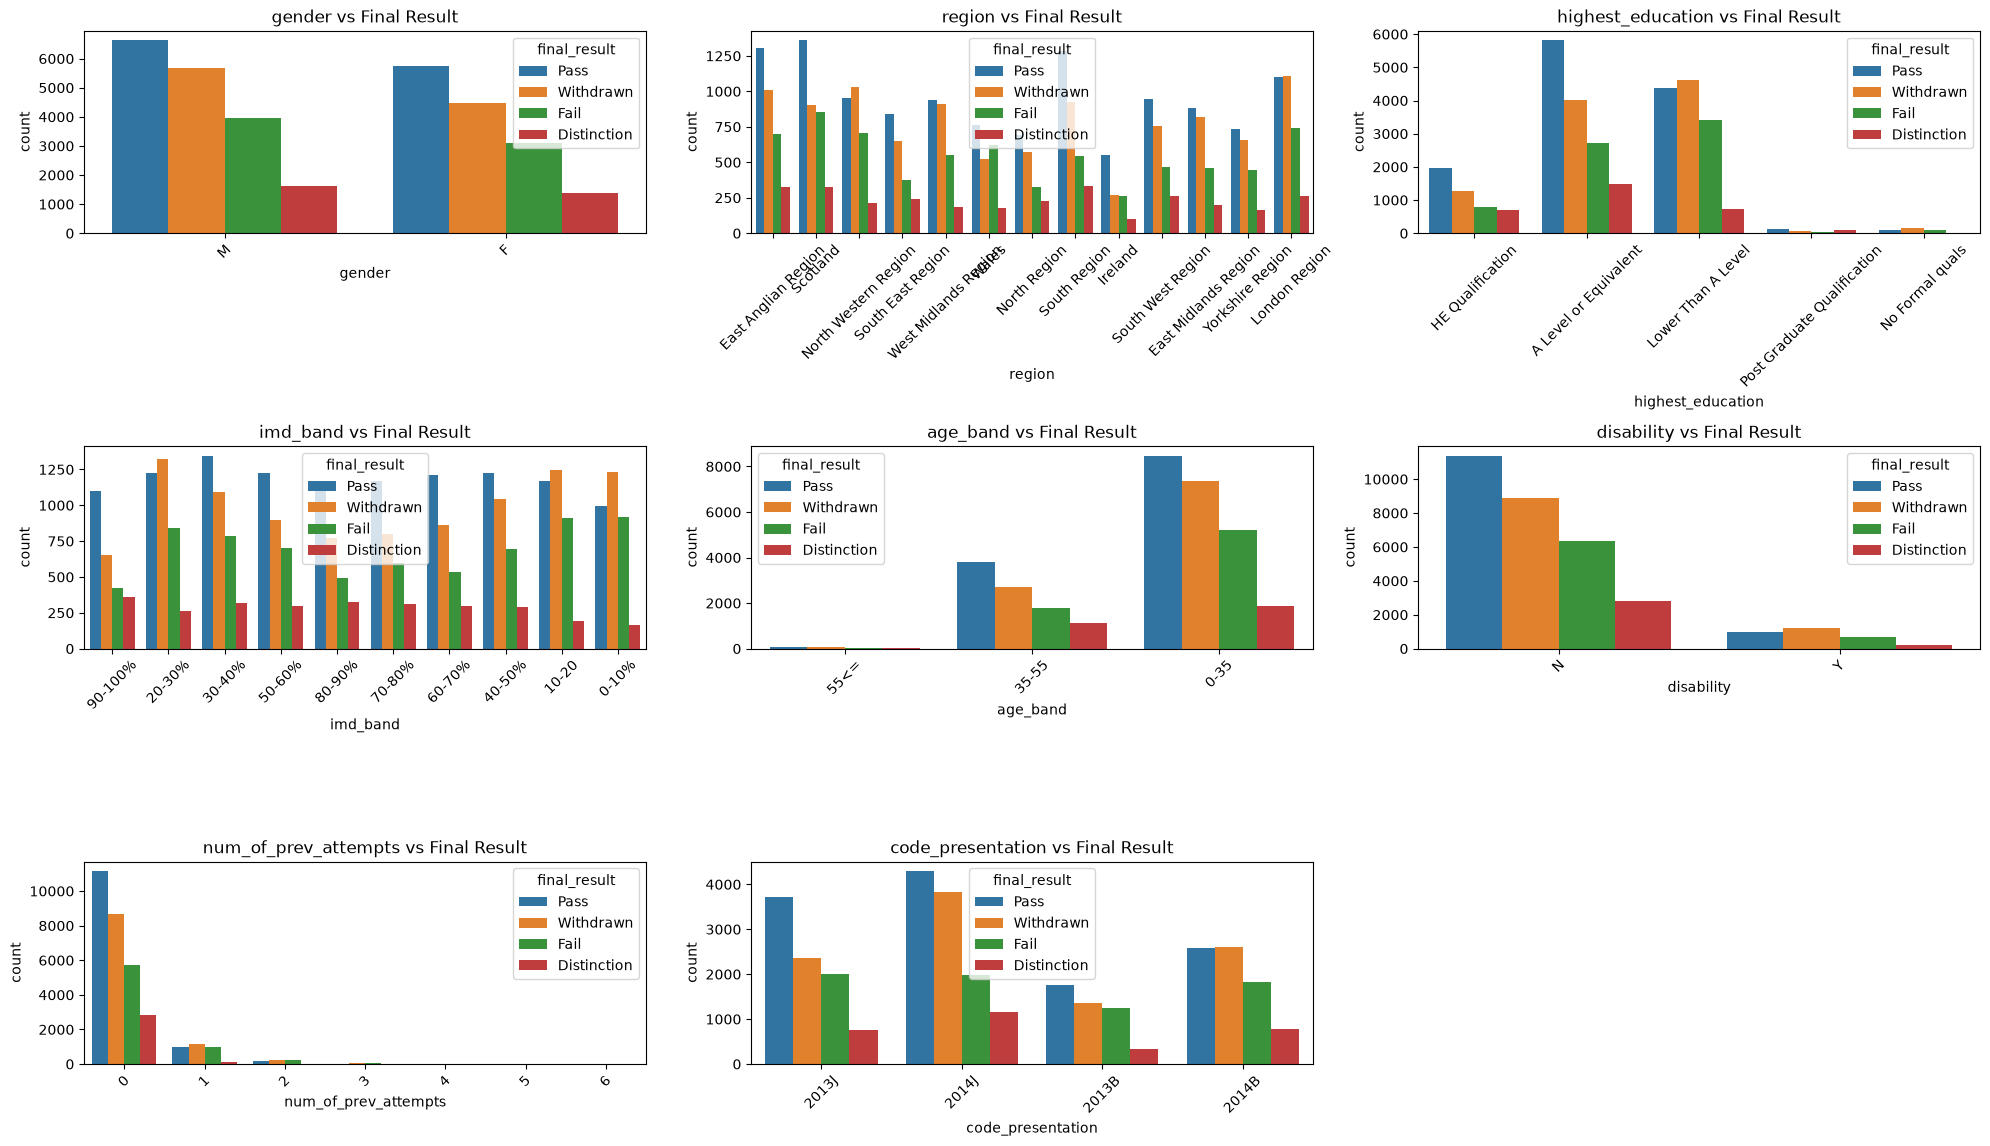

In [11]:
# 1. 10개의 속성 리스트
cat_cols = ["gender", "region", "highest_education", "imd_band", 
            "age_band", "disability", "num_of_prev_attempts", "code_presentation"]

# 2. 전체 크기 설정
plt.figure(figsize=(20, 15))

# 3. 10개 속성을 하나씩 꺼내서 'final_result'와 비교하는 그래프
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i + 1) # 도화지를 4행 3열로 나누어 쏙쏙 채워 넣어요.
    sns.countplot(data=info, x=col, hue="final_result")
    plt.title(f"{col} vs Final Result")
    plt.xticks(rotation=45) # 글자가 겹치지 않게 살짝 돌려줍니다.

plt.tight_layout() # 그래프끼리 부딪히지 않게 간격을 조절합니다.
plt.show()